<h1>About Dataset</h1>

<h3>Context</h3>
<p>Predict behaviour to retain customers.</p>

<h3>Content</h3>
<p>Each row represents a customer, each column contains customer's attributes described in the column metadata.
The dataset includes information about:
  <ul>
    <li>Churn: Customers who left within the last month.</li>
    <li>Customer account information</li>
    <li>Services that a customer has signed up for, such as Phone, Internet, Streaming TV and movies, etc. (Telco -> Some Telecommunications company)</li>
    <li>Demographic information such as Gender, Age, etc.</li>
</ul>
</p>

<h1>Exploration & Data Loading</h1>

In [111]:
import pandas as pd # For working with data in a tabular form
import seaborn as sns # For visualizing the data
import matplotlib.pyplot as plt # For visualizing the data
import numpy as np

In [112]:
df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [113]:
df.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


<h1> Binary Encoding </h1>
<p> For categorical variables with 2 categories.</p>

In [114]:
binary_cols = [col for col in df.columns if len(df[col].unique()) == 2]
for col in binary_cols:
  first_category, second_category = df[col].unique()[0], df[col].unique()[1]
  print(f"Categories of {col}: ", first_category, ",", second_category)

Categories of gender:  Female , Male
Categories of SeniorCitizen:  0 , 1
Categories of Partner:  Yes , No
Categories of Dependents:  No , Yes
Categories of PhoneService:  No , Yes
Categories of PaperlessBilling:  Yes , No
Categories of Churn:  No , Yes


In [115]:
pd.set_option('future.no_silent_downcasting', True)

In [116]:
df[binary_cols] = df[binary_cols].replace({
  "Yes": 1, "No": 0, "Male": 1, "Female": 0
}).astype(np.int64)

In [117]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,...,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,...,Yes,No,No,No,One year,0,Mailed check,56.95,1889.5,0
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,...,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,No,...,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


<h1> Exploring the data in the 'TotalCharges' column </h1>
<p> The data in the TotalCharges column is of the datatype 'object', so we explore the column further to see if it contains a mix of different primitive datatypes. If yes, we can clean it up a bit and convert the column to the proper numeric format.</p>

In [118]:
# df['TotalCharges'] should contain numerical values, however its datatype is object, which suggest that the column may be a mix of different primitive datatypes
df['TotalCharges'].dtype.name

'object'

In [119]:
# Exploring the data in the 'TotalCharges' column
df['TotalCharges'].isnull().value_counts() # No null values in this column

TotalCharges
False    7043
Name: count, dtype: int64

In [120]:
# Profiling the column's primitive data types in the 'TotalCharges' column
df['TotalCharges'].apply(type).value_counts() # All 'objects' in the column have a the primitive 'string' datatype

TotalCharges
<class 'str'>    7043
Name: count, dtype: int64

In [121]:
# Checking if there are any empty strings in the column 'TotalCharges'
empty_string_indexes = df.loc[(df['TotalCharges'].isin(['', ' '])), 'TotalCharges'].index.to_numpy() # Empty strings are present in some rows of the 'TotalCharges' Column
empty_string_indexes

array([ 488,  753,  936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754])

In [122]:
# Checking if there are any strings with non-numeric content in the column 'TotalCharges'
non_numeric_string_indexes = df.loc[df['TotalCharges'].str.contains(r'[^\d.\s]', na=False), 'TotalCharges'].index.to_numpy() # No non-numeric string values aside from the empty strings ('' and ' ')
non_numeric_string_indexes

array([], dtype=int64)

In [123]:
# Coverting the 'TotalCharges' column of 'Object' datatype back to a number, all rows having an empty string are replaced with NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [124]:
# There are 11 rows with NaN as their Total Charges
df['TotalCharges'].isna().value_counts()

TotalCharges
False    7032
True       11
Name: count, dtype: int64

<h1> One-Hot Encoding </h1>
<p> For categorical variables with more than 2 categories </p>

In [125]:
one_hot_cols = [col for col in df.columns if len(df[col].unique()) > 2 and type(df[col].dropna().sample(n=1).values[0]) is str]
one_hot_cols.remove('customerID')
one_hot_cols

['MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaymentMethod']

In [126]:
# Displaying the value counts of categorical columns
print("Value counts of the categorical columns in the Dataframe df: \n")
for col in one_hot_cols:
  print(df[col].value_counts(), "\n\n")

Value counts of the categorical columns in the Dataframe df: 

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64 


InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64 


OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64 


OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64 


DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64 


TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64 


StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64 


StreamingMovies
No                     2785
Yes                    2732
No inter

In [127]:
df = pd.get_dummies(df, columns=one_hot_cols, drop_first=True)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,...,False,False,False,False,False,False,False,False,True,False
1,5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.50,...,False,False,False,False,False,True,False,False,False,True
2,3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,...,False,False,False,False,False,False,False,False,False,True
3,7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,...,True,False,False,False,False,True,False,False,False,False
4,9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,...,False,False,False,False,False,False,False,False,True,False


<h1> Data Cleaning and Exploration </h1>
<p> After transforming one column ('TotalCharges') of the Dataframe df, there is still some more Data exploration and cleaning to do. </p>

In [128]:
# Customer ID is irrelevant for Churn prediction
df = df.drop('customerID', axis=1)

In [129]:
# Converting all the True/False (boolean values) to 0/1 (numeric values)
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,1,84.80,1990.50,0,...,1,0,1,0,1,1,0,0,0,1
7039,0,0,1,1,72,1,1,103.20,7362.90,0,...,0,0,1,0,1,1,0,1,0,0
7040,0,0,1,1,11,0,1,29.60,346.45,0,...,0,0,0,0,0,0,0,0,1,0
7041,1,1,1,0,4,1,1,74.40,306.60,1,...,0,0,0,0,0,0,0,0,0,1


In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int64  
 11  Mult

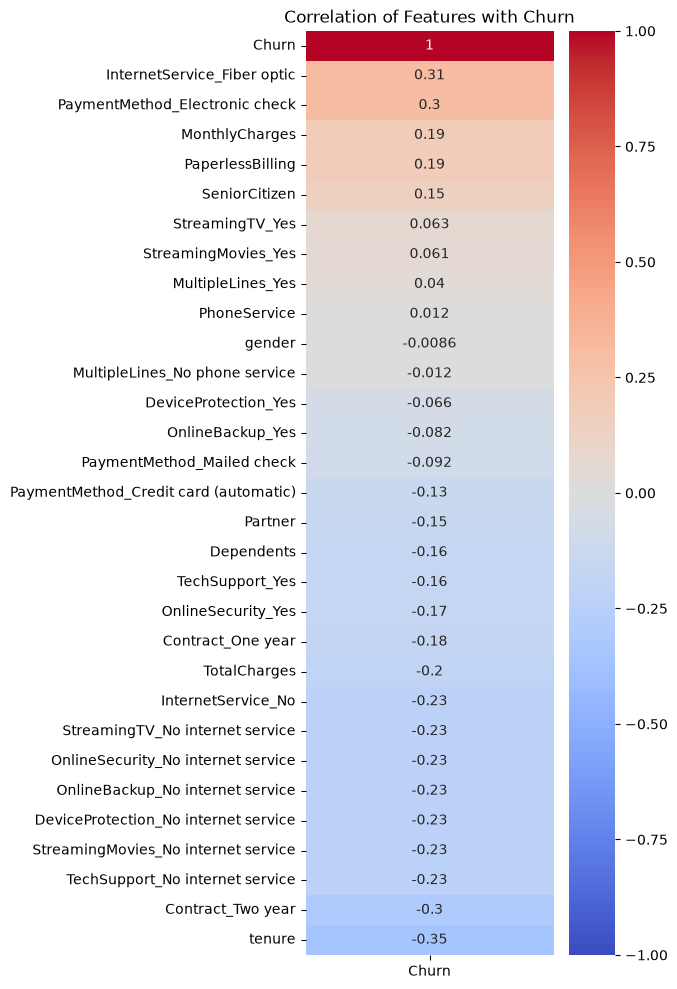

In [131]:
# Compute a correlation matrix for numeric columns
corr_matrix = df.corr(numeric_only=True)

# We focus on correlation only with Churn
churn_corr = corr_matrix[['Churn']].sort_values(by="Churn", ascending=False)

# Plot heatmap
plt.figure(figsize=(4, 12))
sns.heatmap(data=churn_corr, annot=True, cmap="coolwarm", vmax=1, vmin=-1)
plt.title("Correlation of Features with Churn")
plt.show()

<p>Negative value implies that a customer is less likely to churn
tenure (-0.35) (Customers who stay longer) => less likely to churn

Positive value implies that a customer is more likely to churn
InternetService_Fiber optic (+0.31) (Customers with Fiber optic Internet service) => more likely to churn</p>

<h1>Looking for Multicollinearity</h1>
<p> Multicollinearity refers to features that offer the same information and makes the model redundant.</p>

In [132]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'Churn', 'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [133]:
# Checking if columns containing "No internet service" are redundant
no_internet_service_cols = [col for col in df.columns if 'No internet service' in col]
df[no_internet_service_cols].eq(df[no_internet_service_cols[0]], axis=0).all(axis=1).value_counts() # All of them contain the same information about whether a customer has internet service or not


True    7043
Name: count, dtype: int64

In [134]:
# Combining redundant columns to a single No_internet_service column
df['No_internet_service'] = (
  df['OnlineSecurity_No internet service'] |
  df['OnlineBackup_No internet service'] |
  df['DeviceProtection_No internet service'] |
  df['TechSupport_No internet service'] |
  df['StreamingTV_No internet service'] |
  df['StreamingMovies_No internet service']
).astype(np.int64)

# Removing redundant columns which have been combined already to form the  from the Dataframe df
df = df.drop(columns=[col for col in df.columns if 'No internet service' in col], axis=1)

In [135]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,No_internet_service
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,1,0,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,1,0,0,0,1,0,0,0,1,0
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,1,0
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,1,0,0,1,0,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,1,0,0


In [136]:
df['MultipleLines_No phone service'].value_counts()

MultipleLines_No phone service
0    6361
1     682
Name: count, dtype: int64

In [137]:
df['PhoneService'].value_counts()

PhoneService
1    6361
0     682
Name: count, dtype: int64

In [138]:
# Removing the redundancy from the Phone Service related columns
df['No_phone_service'] = df['MultipleLines_No phone service']
df = df.drop('MultipleLines_No phone service', axis=1)

In [139]:
# Checking the redundancy of the No_phone_service and PhoneService columns
df['PhoneService'].eq((~df['No_phone_service'].astype(bool)).astype(int), axis=0).value_counts() # Redundant columns, one is essentially a negation of the other, both are not needed

True    7043
Name: count, dtype: int64

In [140]:
# Removing the No_phone_service column due to redundancy
df = df.drop('No_phone_service', axis=1)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,No_internet_service
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,1,0,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,1,0,0,0,1,0,0,0,1,0
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,1,0
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,1,0,0,1,0,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,1,0,0


In [141]:
# Checking the redundancy between the No_Internet_Service columns and the InternetService columns
df['No_internet_service'].eq(df['InternetService_No'], axis=0).value_counts() # Redundant, both columns are essentially the same, one of them can be dropped

True    7043
Name: count, dtype: int64

In [142]:
# Dropping the InternetService_No column due to redundancy
df = df.drop('InternetService_No', axis=1)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,No_internet_service
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,1,0,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,1,0,0,0,1,0,0,0,1,0
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,1,0
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,1,0,0,1,0,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,1,0,0


In [143]:
# Checking the relation between 'TotalCharges' and 'MonthlyCharges'
cols = ['MonthlyCharges', 'tenure', 'TotalCharges']
temp = pd.concat([df[cols], pd.DataFrame(data=df['MonthlyCharges'] * df['tenure'], columns=['MonthlyCharges * tenure'])], axis=1)
temp

,MonthlyCharges,tenure,TotalCharges,MonthlyCharges * tenure
0,29.85,1,29.85,29.85
1,56.95,34,1889.50,1936.30
2,53.85,2,108.15,107.70
3,42.30,45,1840.75,1903.50
4,70.70,2,151.65,141.40
...,...,...,...,...
7038,84.80,24,1990.50,2035.20
7039,103.20,72,7362.90,7430.40
7040,29.60,11,346.45,325.60
7041,74.40,4,306.60,297.60


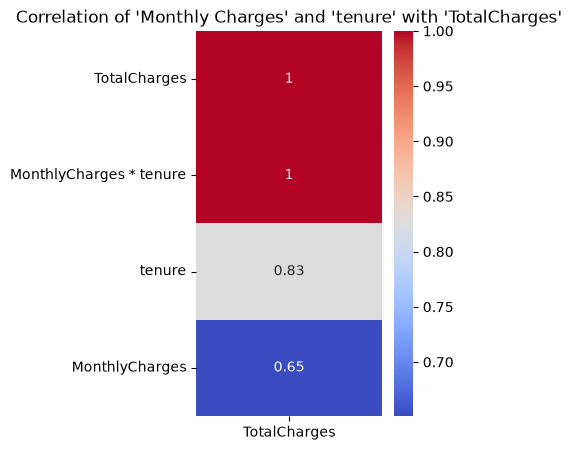

In [144]:
# Calculating how correlated the columns in the Dataframe temp are with 'TotalCharges'
temp_corr_matrix = temp.corr(numeric_only=True)

temp_corr = temp_corr_matrix[['TotalCharges']].sort_values(by='TotalCharges', ascending=False)

plt.figure(figsize=(3, 5))
sns.heatmap(data=temp_corr, cmap='coolwarm', annot=True)
plt.title("Correlation of 'Monthly Charges' and 'tenure' with 'TotalCharges'")
plt.show()

In [145]:
# As expected 'MonthlyCharges' * 'tenure' is highly correlated with 'TotalCharges', and thus the 'TotalCharges' column can be dropped as it offers no new information, it just combines two already existing pieces of information, i.e. MonthlyCharges and tenure
df = df.drop(columns=['TotalCharges'])
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,Churn,MultipleLines_Yes,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,No_internet_service
0,0,0,1,0,1,0,1,29.85,0,0,...,0,0,0,0,0,0,0,1,0,0
1,1,0,0,0,34,1,0,56.95,0,0,...,1,0,0,0,1,0,0,0,1,0
2,1,0,0,0,2,1,1,53.85,1,0,...,0,0,0,0,0,0,0,0,1,0
3,1,0,0,0,45,0,0,42.30,0,0,...,1,1,0,0,1,0,0,0,0,0
4,0,0,0,0,2,1,1,70.70,1,0,...,0,0,0,0,0,0,0,1,0,0


In [146]:
# Checking which rows have any missing values in any of their columns
df.isna().any(axis=1).value_counts() # No missing values in any of the cells of the dataframe (if the o/p is False 7043)

False    7043
Name: count, dtype: int64

In [147]:
# All columns are of two datatypes: int64 or float64
df.dtypes.value_counts()

int64      22
float64     1
Name: count, dtype: int64

In [148]:
# Checking for any rogue strings, empty spaces or tabs across all cells in the Dataframe df
# Stack all cells into a single series, cast the values to a string, applies regex pattern, unstacks back to its original shape, and checks row-by-row if any match exists
re = r'^[a-zA-Z\t\n]*$'
df.stack().astype(str).str.contains(re).unstack().any(axis=1).value_counts() # No such types of rogue inputs (if the o/p is False 7043)

False    7043
Name: count, dtype: int64

In [149]:
# Checking if there are any infinite values or missing values across all rows of the Dataframe df
df.isin([np.inf, -np.inf, np.nan]).any(axis=1).value_counts()

False    7043
Name: count, dtype: int64

In [150]:
# Run VIF (Variance Inflation Factor) to check Multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = df.drop(columns=['Churn'])

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values(by='VIF', ascending=False)

vif_data

,feature,VIF
7,MonthlyCharges,178.725857
5,PhoneService,41.770635
9,InternetService_Fiber optic,12.970860
4,tenure,7.617049
21,No_internet_service,6.748854
15,StreamingMovies_Yes,4.255333
14,StreamingTV_Yes,4.136170
17,Contract_Two year,3.442472
6,PaperlessBilling,2.954085
19,PaymentMethod_Electronic check,2.947580


<p>Multicollinearity can be contained by reducing redundancy such as dropping redundant features, using regularization techniques sucha s Ridge or Lasso regression, or using Tree-based methods which are less sensitive to multicollinearity</p>

<h1>Machine Learning</h1>

In [158]:
# Taking a look at how the categorical Churn column's values are distributed
# There is an evident class imbalance problem
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64